In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from matplotlib.colors import LogNorm
from scipy import integrate
from tqdm import tqdm
from astropy import units as u
# from astropy import constants as c
from pathlib import Path

# PlatoSim imports
import platosim.utilities as ut
from platosim.matplotlibrc import setup_paper
setup_paper()

# Ignore warnings
import warnings
warnings.simplefilter("ignore")

# Expand notebook
from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [19]:
np.rad2deg(-0.01873397222223616)

-1.073377541849452

In [7]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = '/lhome/nicholas/Nextcloud/latex/paperSMBHB/figures'

The methods below have been adapted directly from D'Orazio(2018) so if you want to see the equations you can see them there.

In [8]:
G = 6.674e-8        # [cm^3g^-1s^-2]
c = 2.998 * 10**10  # [cm/s
h = 6.62607015e-27  # Planck constant in erg·s
k_B = 1.380649e-16  # Boltzmann constant in erg/K
M_sun = 1.989e33    # [g]

def r_ISCO(M):
    M_g = M * M_sun #total mass in g
    return 6 * G * M_g / c**2 # in cm

def orbital_radius(M, period_rest):
    M_g = M * M_sun
    # Orbital period in binary rest frame [s]
    T_s = period_rest * ut.year()
    return ((G * M_g * T_s**2) / (4 * np.pi**2))**(1/3) 

def accretion_rate(M):
    radiative_efficiency = 0.1
    M_g = M * M_sun  # g
    return 2.26 * 10**-2 * (radiative_efficiency / 0.1) **-1 * (M_g/10**6) / ut.year()

def Temp(q, r, M):
    M_g = M * M_sun  # g
    sigma = 5.67 * 10 **-5 # erg cm^-2s^-1K^-4
    # power = 3 * G * M_g * accretion_rate(M) * (1 - np.sqrt(r_ISCO(M) / r)) / (8 * np.pi * r**3)
    power = 3 * G * q * M_g / (1+q) * accretion_rate(q * M / (1 + q)) * (1 - np.sqrt(r_ISCO(q * M / (1 + q)) / r)) / (8 * np.pi * r**3)
    return (power / sigma)**0.25  

def planck_wavelength(wavelength, T):
    numerator = 2 * h * c**2
    exponent = (h * c) / (wavelength * k_B * T)
    denominator = (wavelength**5) * (np.exp(exponent) - 1)
    return numerator / denominator

def flux(wavelength, r, q, M, period, z):
    period_rest = period / (1 + z)
    a = orbital_radius(M, period_rest)
    r_isco = r_ISCO(q * M / (1 + q))
    condition = (r_isco < r) & (r < 0.27 * a * q**0.3)
    flux_values = np.where(
        condition,
        np.pi * planck_wavelength(wavelength, Temp(q, r, M)),
        0
    )
    return flux_values

def einstein_radius(q, M, I, period, time, z):
    period_rest = period / (1 + z)
    a = orbital_radius(M, period_rest)
    
    M_g = M * M_sun  # g
    R_p = 2 * G * M_g / ((1 + q) * c**2) # primary Schwarzchild in cm
    R_s = 2 * G * M_g * q / ((1 + q) * c**2) # primary Schwarzchild in cm
    
    primary = np.sqrt(2 * R_p * a * np.cos(I) * np.sin(2 * np.pi * time / period)) # in cm
    secondary = np.sqrt(2 * R_s * a * np.cos(I) * np.sin(-np.pi + 2 * np.pi * time / period)) # in cm
    return primary, secondary


def position_uv(q, M, I, period, time, z):
    period_rest = period / (1 + z)
    a = orbital_radius(M, period_rest)
    
    if 0 < time / period < 0.5:
        phase = np.sqrt(np.cos(2 * np.pi * time / period) ** 2 + (np.sin(I) ** 2) * np.sin(2 * np.pi * time / period) ** 2)
        # phase = np.cos(2 * np.pi * time / period)
        u_0 = (a * phase / einstein_radius(q, M, I, period, time, z)[0])

    else:
        phase = np.sqrt(np.cos(-np.pi + 2 * np.pi * time / period) ** 2 + np.sin(I) ** 2 * np.sin(-np.pi + 2 * np.pi * time / period) ** 2)
        u_0 = (a * phase / einstein_radius(q, M, I, period, time, z)[1])
        
    v_0 = np.arctan(np.sin(I) * np.tan(2 * np.pi * time / period))
    return u_0, v_0 

def M_point_u(u): #just a dummy function, not point-source magnification
    return (u ** 2 + 2) / (np.sqrt(u**2 + 4))

def r(u, v, u_0, v_0, r_E, J):
    r_star = np.sqrt(u_0 ** 2 + u ** 2 - 2 * u_0 * u * np.cos(v - v_0)) * r_E 
    sin_phi = (u * np.sin(v) - u_0 * np.sin(v_0)) / np.sqrt((u * np.sin(v) - u_0 * np.sin(v_0)) ** 2 + (u * np.cos(v) - u_0 * np.cos(v_0)) ** 2)

    phi = np.arcsin(sin_phi)
    
    #return r_star * np.sqrt(np.cos(phi) ** 2 + np.sin(phi) ** 2 / (np.cos(np.pi / 2 - J) ** 2))
    return r_star * np.sqrt(np.cos(phi) ** 2 + np.sin(phi) ** 2 / (np.cos(np.pi / 2 - J) ** 2)), r_star, phi

def M_point(u): #point-source magnification
    return (u ** 2 + 2) / (u * np.sqrt(u**2 + 4))

In [9]:
def run_model(time, wvl_cm, z, T, I, J, M, q, u_max=5, u_grid=300, v_grid=100):
    
    # Grid for accretion disc 
    u_array = np.linspace(0, u_max, u_grid)
    delta_u = u_max / u_grid
    v_array = np.linspace(0, 2 * np.pi, v_grid)
    delta_v = 2 * np.pi / v_grid
    u_grid, v_grid = np.meshgrid(u_array, v_array)

    # Calculate self-lensing in phase
    mag_e = []
    mag_p = []

    for t in tqdm(time, desc="Processing time steps"):
        u_0, v_0 = position_uv(q, M, I, T, t, z)
        r_E = einstein_radius(q, M, I, T, t, z)[0]

        radius = r(u_grid, v_grid, u_0, v_0, r_E, J)[0]
        flux_values = flux(wvl_cm, radius, q, M, T, z)
        M_point_u_values = M_point_u(u_grid)

        numer = np.sum(flux_values * M_point_u_values * delta_u * delta_v)
        denom = np.sum(flux_values * u_grid * delta_u * delta_v)
        mag_e.append(numer / denom)

    for t in time:
        u_0, v_0 = position_uv(q, M, I, T, t, z)
        mag_p.append(M_point(u_0))
        
    return mag_p, mag_e

## Finite-Source Magnification Light Curve

This part is slightly sensitive to the number of iterations (num1, num2, etc). The numbers below were fine-tuned to my purposes.

### Reproduce Fig. 3 of D'Orazio+2018

Here compare to the left and right panel of Fig.3. Below we can see that the poin-source magnification for $I=3.5^{\circ}$ equals to $\mathcal{M}=2.2$. This is expected as pointed out by D'Orazio+2028: "*when $N_E = 0.5$ (i.e. $I=3.5^{\circ}$), $\mathcal{M} \approx 2.2$ (larger than seen in Fig. 3 because the Doppler calculation assumes that each binary component contributes equally to the total brightness of the system)*." 

In [10]:
# Phase array
cols = ['royalblue', 'orange', 'tomato', 'purple']

<IPython.core.display.Javascript object>


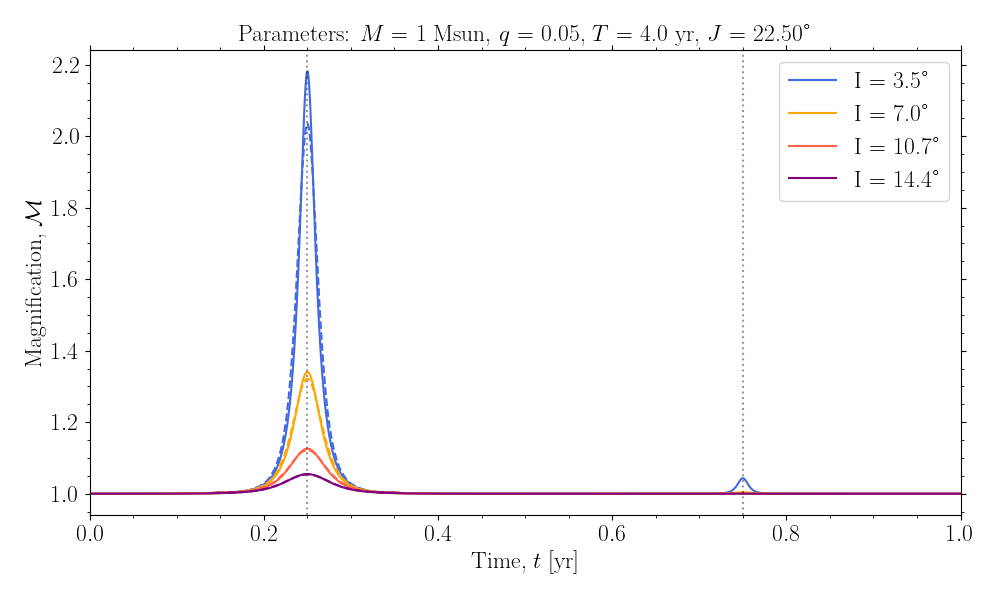

Processing time steps: 100%|████████████████████████████████████| 1000/1000 [00:01<00:00, 895.65it/s]


In [11]:
# Physical parameters
z  = 0 
T  = 4
M  = 1e9
q = 0.05
I_binary = np.deg2rad([3.5, 7.0, 10.7, 14.4])
J = np.pi / 8
wvl_cm = 550e-7
time = np.linspace(0, T, 1000)

# Make plot
plt.figure(figsize=(10,6))
for I, col in zip(I_binary, cols):
    mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q)
    plt.plot(time/T, mag_p, '-',  c=col, label=f'I = {np.rad2deg(I):.1f}°')
    plt.plot(time/T, mag_e, '--', c=col) 
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel(r'Time, $t$ [yr]')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.title('Parameters: ' +
          rf'$M$ = {M/1e9:.0f} Msun, ' + 
          rf'$q$ = {q:.2f}, ' + 
          rf'$T$ = {T:.1f} yr, ' +
          rf'$J$ = {np.rad2deg(J):.2f}°'
         )
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

<IPython.core.display.Javascript object>


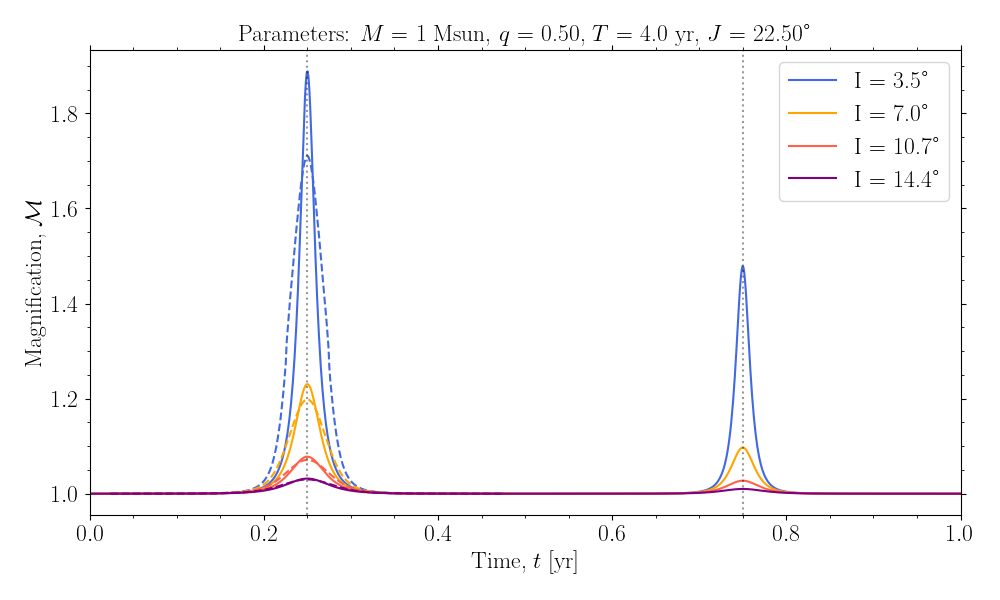

Processing time steps: 100%|█████████████████████████████████████| 1000/1000 [00:12<00:00, 80.17it/s]


In [12]:
# Physical parameters
z = 0 
T = 4
M = 1e9
q = 0.5
I_binary = np.deg2rad([3.5, 7.0, 10.7, 14.4])
J = np.pi / 8
wvl_cm = 550e-7
time = np.linspace(0, T, 1000)

# Plot the results against binary inclination
plt.figure(figsize=(10,6))
for I, col in zip(I_binary, cols):
    mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q, u_max=20, u_grid=500, v_grid=500)
    plt.plot(time/T, mag_p, '-',  c=col, label=f'I = {np.rad2deg(I):.1f}°')
    plt.plot(time/T, mag_e, '--', c=col)
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel(r'Time, $t$ [yr]')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.title('Parameters: ' +
          rf'$M$ = {M/1e9:.0f}e9 Msun, ' + 
          rf'$q$ = {q:.2f}, ' + 
          rf'$T$ = {T:.1f} yr, ' +
          rf'$J$ = {np.rad2deg(J):.2f}°'
         )
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

As function of total binary mass: $M$

<IPython.core.display.Javascript object>


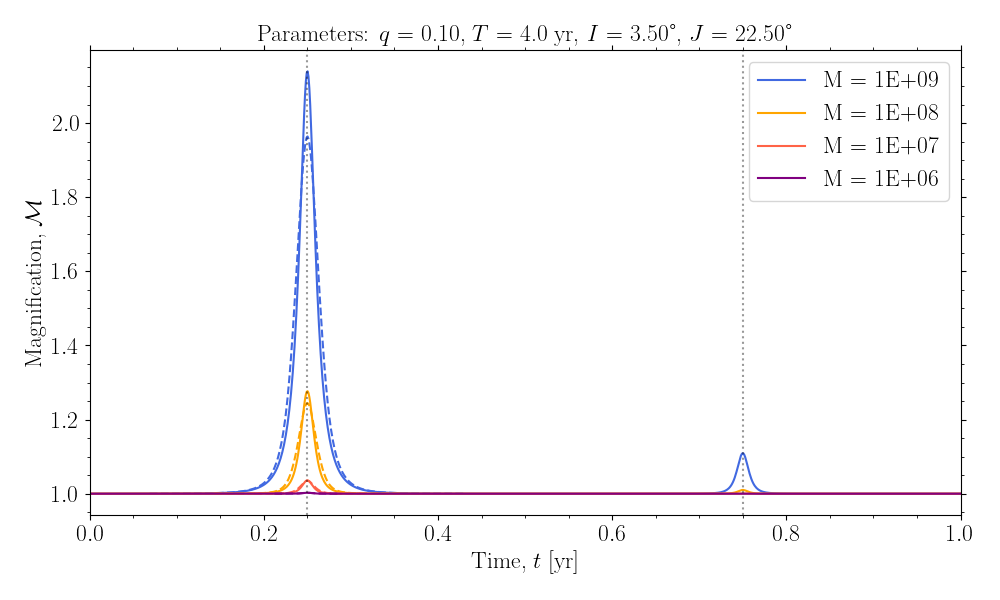

Processing time steps: 100%|█████████████████████████████████████| 1000/1000 [00:11<00:00, 85.54it/s]


In [13]:
# Physical parameters
z = 0 
T = 4
M_binary = [1e9, 100e6, 10e6, 1e6]
q = 0.1
I = np.deg2rad(3.5)
J = np.pi / 8
wvl_cm = 550e-7
time = np.linspace(0, T, 1000)

# Plot the results against mass ratios q 
plt.figure(figsize=(10,6))
for M, col in zip(M_binary, cols):
    mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q, u_max=10, u_grid=500, v_grid=500)
    plt.plot(time/4, mag_p, '-', c=col, label=f'M = {M:.0E}')
    plt.plot(time/4, mag_e, '--', c=col)  
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel(r'Time, $t$ [yr]')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.title('Parameters: ' +
          rf'$q$ = {q:.2f}, ' + 
          rf'$T$ = {T:.1f} yr, ' +
          rf'$I$ = {np.rad2deg(I):.2f}°, ' +
          rf'$J$ = {np.rad2deg(J):.2f}°'
         )
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

As function of mass ratios: $q$

<IPython.core.display.Javascript object>


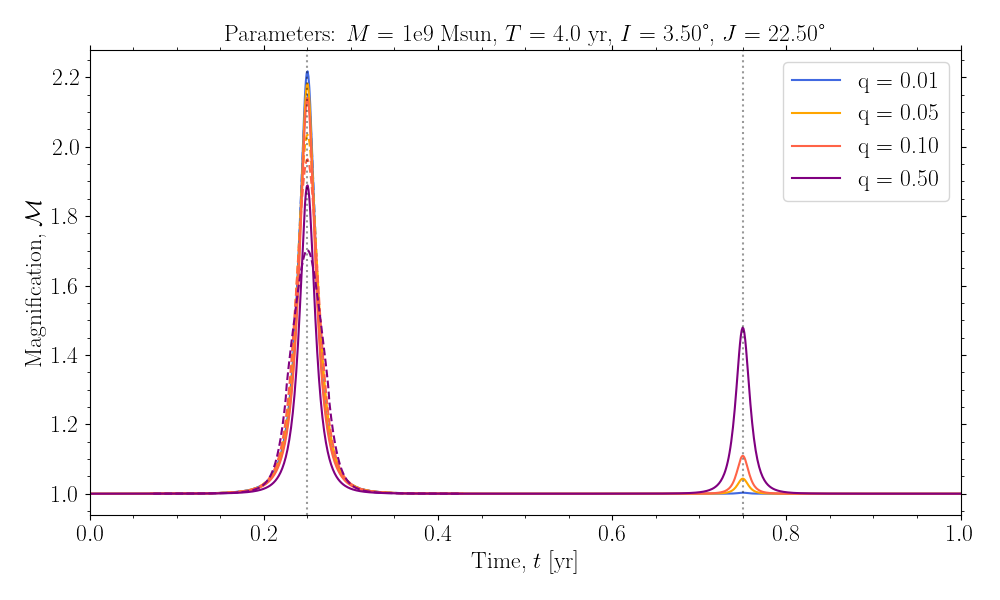

Processing time steps: 100%|█████████████████████████████████████| 1000/1000 [00:11<00:00, 85.85it/s]


In [14]:
# Physical parameters
z = 0 
T = 4
M = 1e9
q_binary = [0.01, 0.05, 0.1, 0.5]
I = np.deg2rad(3.5)
J = np.pi / 8
wvl_cm = 550e-7
time = np.linspace(0, T, 1000)

# Plot the results against mass ratios q 
plt.figure(figsize=(10,6))
for q, col in zip(q_binary, cols):
    mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q, u_max=10, u_grid=500, v_grid=500)
    plt.plot(time/4, mag_p, '-', c=col, label=f'q = {q:.2f}')
    plt.plot(time/4, mag_e, '--', c=col)  
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel(r'Time, $t$ [yr]')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.title('Parameters: ' +
          rf'$M$ = {M/1e9:.0f}e9 Msun, ' +  
          rf'$T$ = {T:.1f} yr, ' +
          rf'$I$ = {np.rad2deg(I):.2f}°, ' +
          rf'$J$ = {np.rad2deg(J):.2f}°'
         )
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

As function of orbital period in binary rest frame: $T$

<IPython.core.display.Javascript object>


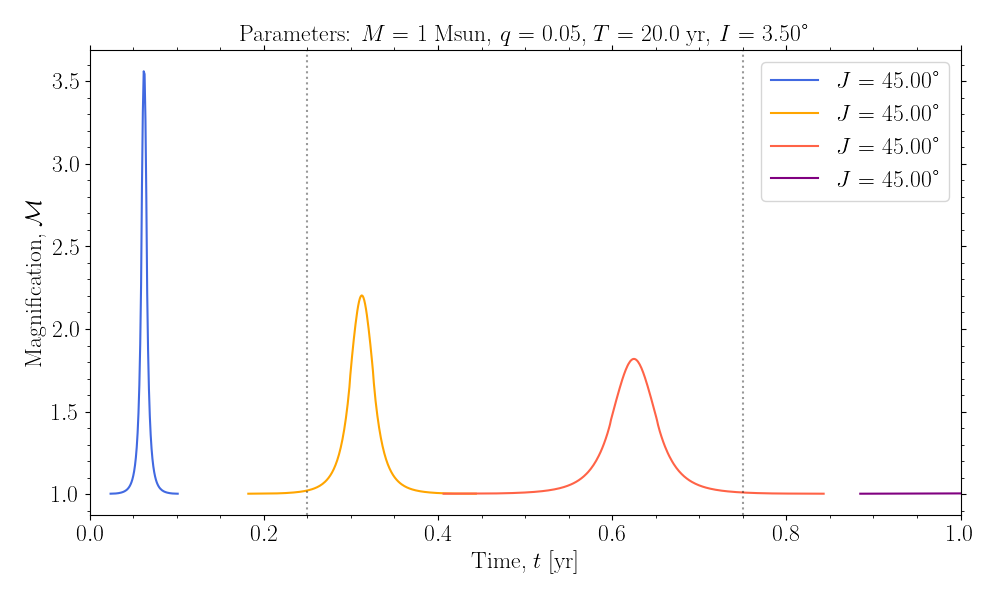

Processing time steps: 100%|█████████████████████████████████████| 1000/1000 [00:10<00:00, 95.56it/s]


In [15]:
# Physical parameters
z = 0 
T_binary = [1, 5, 10, 20]
M = 1e9
q = 0.05
I = np.deg2rad(3.5)
J = np.pi/4
wvl_cm = 550e-7

# Plot the results against mass ratios q 
plt.figure(figsize=(10,6))
for T, col in zip(T_binary, cols):
    mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q, u_max=5, u_grid=500, v_grid=500)
    plt.plot(time/4, mag_e, '-', c=col, label=rf'$J$ = {np.rad2deg(J):.2f}°')
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel(r'Time, $t$ [yr]')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.title('Parameters: ' +
          rf'$M$ = {M/1e9:.0f} Msun, ' +
          rf'$q$ = {q:.2f}, ' + 
          rf'$T$ = {T:.1f} yr, ' +
          rf'$I$ = {np.rad2deg(I):.2f}°'
         )
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

As function of the secondary disc inclination: $J$

<IPython.core.display.Javascript object>


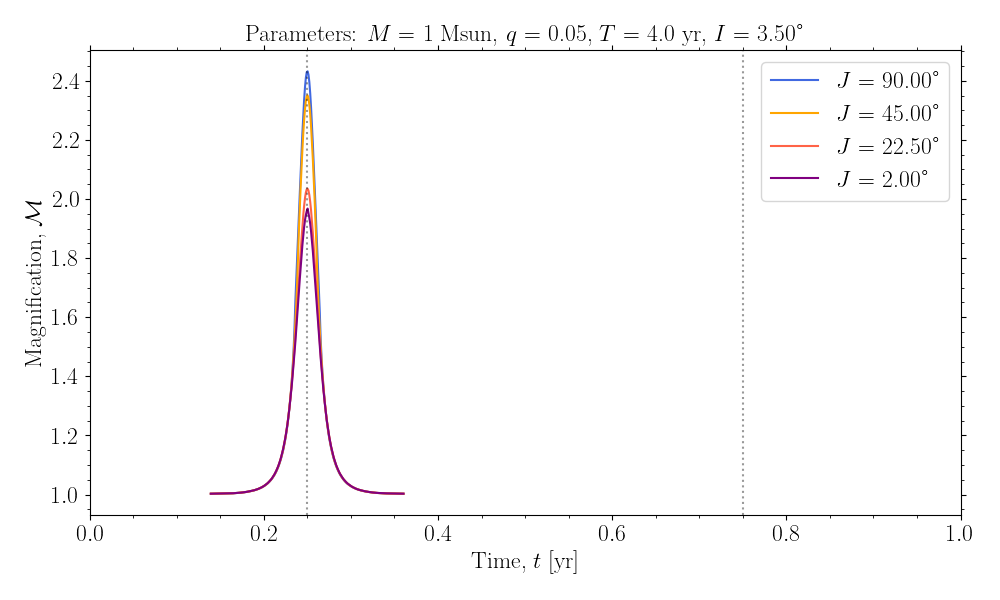

Processing time steps: 100%|█████████████████████████████████████| 1000/1000 [00:15<00:00, 65.78it/s]


In [17]:
# Physical parameters
z = 0 
T = 4
M = 1e9
q = 0.05
I = np.deg2rad(3.5)
J_binary = [np.pi/2, np.pi/4, np.pi/8, np.pi/90]
wvl_cm = 550e-7
time = np.linspace(0, T, 1000)

# Plot the results against mass ratios q 
plt.figure(figsize=(10,6))
for J, col in zip(J_binary, cols):
    mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q, u_max=5, u_grid=500, v_grid=500)
    plt.plot(time/4, mag_e, '-', c=col, label=rf'$J$ = {np.rad2deg(J):.2f}°')
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel(r'Time, $t$ [yr]')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.title('Parameters: ' +
          rf'$M$ = {M/1e9:.0f} Msun, ' +
          rf'$q$ = {q:.2f}, ' + 
          rf'$T$ = {T:.1f} yr, ' +
          rf'$I$ = {np.rad2deg(I):.2f}°'
         )
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

### Model over LSST passbands

In [13]:
# Physical parameters
q = 0.1
M = 1e6
z = 0.962
T = 1
J = np.pi / 4 
I = 0.1

# Time array
N = 1000
time = np.linspace(0, T, N)

In [ ]:
fig = plt.figure(figsize=(8,5))

wvl_cm = np.array([150, 230, 806, 3400, 550]) * 1e7
mag_p = np.zeros((len(wvl_cm), N))
mag_e = np.zeros((len(wvl_cm), N))

for i,w in zip(range(len(wvl_cm)), wvl_cm):
#     mag_p[i,:], mag_e[i,:] = run_model(time, w, z, T, I, J, M, q, u_max=50, u_grid=5000, v_grid=5000)
    mag_p, mag_e = run_model(time, w, z, T, I, J, M, q, u_max=50, u_grid=5000, v_grid=5000)
    plt.plot(time/T, mag_e, ':', alpha=1.0, c='k', label='Point source')


<IPython.core.display.Javascript object>

Processing time steps:   1%|▌                                                                                                | 6/1000 [00:15<39:52,  2.41s/it]

In [ ]:
fig = plt.figure(figsize=(8,5))

plt.plot(time/T, mag_p[0,:], ':', alpha=1.0, c='k',         label='Point source')
plt.plot(time/T, mag_e[0,:], '-', alpha=0.5, c='magenta',   label='LSST 150 nm')
plt.plot(time/T, mag_e[1,:], '-', alpha=0.7, c='royalblue', label='LSST 230 nm')
plt.plot(time/T, mag_e[2,:], '-', alpha=0.5, c='orange',    label='LSST 806 nm')
plt.plot(time/T, mag_e[3,:], '-', alpha=0.5, c='red',       label='LSST 3400 nm')
plt.plot(time/T, mag_e[4,:], '-', alpha=1.0, c='k',         label='PLATO 550 nm')

# plt.title('$I = 0.28^{\circ}$, $J = 45^{\circ}$')
# plt.xlim([0.24, 0.26])
plt.xlabel(r'Phase, $t / T$')
plt.ylabel('Magnification, $\mathcal{M}$')
plt.legend()
plt.tight_layout()
plt.locator_params(axis='x', nbins=5) 

# Save figure
# fig.savefig(f'{fdir}/lensing_chromatic.png', bbox_inches='tight', dpi=300)

### Model Spikey

In [ ]:
# Parameters relating to Spikey
z  = 0.962
P  = 1.144
T  = P * (1 + z)

M1 = 10**7.4 * u.M_sun                                                           
M2 = 10**6.7 * u.M_sun
M  = (M1 + M2).value
q  = (M2 / M1).value

i  = np.rad2deg(np.arccos(0.140)) 
I  = np.deg2rad(90 - i)
J  = np.pi / 4  

# e  = 0.524
# w  = 1.477
# alpha = 2.09
# F_lum = 0.89

# Initialise model
wvl_cm = 600e-7

# Time array
N = 1000
time = np.linspace(0, T, N)

In [ ]:
plt.figure(figsize=(10,6))

mag_p, mag_e = run_model(time, wvl_cm, z, T, I, J, M, q, u_max=10, u_grid=500, v_grid=500)
plt.plot(time/T, mag_p, '-',  c=cols[2], label='Point')
plt.plot(time/T, mag_e, '--', c=cols[2], label='Finite')
    
plt.axvline(x=0.25, ls=':', c='k', alpha=0.4)
plt.axvline(x=0.75, ls=':', c='k', alpha=0.4)
plt.xlabel('Time [yr]')
plt.ylabel('Magnification')
plt.title(f'Parameters: q = {q:.2f}, I = {np.rad2deg(I):.2f}°, J = {np.rad2deg(J):.2f}°')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout();

Code that expand the time series and adjusted to $t_0$

In [ ]:
N = 1000
time  = np.linspace(0, T, N)
phase = time / T
M_point = mag_p
t_dur = 5
t0 = 100 / 365.25 # [d]

# Roll the phase array using t0
p0 = t0 / T
phase_new = p0 - 0.25
if phase_new < 0:
    phase_new += 1
dex = ut.findNearestIndex(time/T, phase_new)
M_point = np.roll(M_point, dex)

# Extend to lenght of timeseries to total duration
phase_ext = t_dur / T
if t_dur > T:    
    phase_num = int(np.floor(phase_ext))
    for p in range(1, phase_num+1):
        dex = ut.findNearestIndex(phase, phase_ext - p)
        time    = np.append(time, time[-1]+time[:dex])
        M_point = np.append(M_point, M_point[:dex])
elif t_dur < T:
    phase_ext = t_dur / T
    dex = ut.findNearestIndex(phase, phase_ext)
    time    = time[:dex]
    M_point = M_point[:dex]

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(time, M_point, '-',  c=cols[2], label='Point')
# plt.plot(time, M_finit, '--', c=cols[2], label='Finite')
# plt.axvline(x=0.25*T, ls=':', c='k', alpha=0.4)
# plt.axvline(x=0.75*T, ls=':', c='k', alpha=0.4)
plt.xlabel('Time [yr]')
plt.ylabel('Magnification')
plt.title(f'Parameters: q = {q:.2f}, I = {np.rad2deg(I):.2f}°, J = {np.rad2deg(J):.2f}°')
plt.xlim(0, t_dur)
plt.legend()
plt.tight_layout();

## Probability of Finite-Source Flares

The code below will take a ~hours to compile.

In [ ]:
# num3 = 300
# I_array = np.linspace(0, 1, num3)
# J = np.pi / 2
# M_array = np.logspace(5, 9.5, num=50)
# z_array = np.linspace(0, 6 , num=50)
# period_array = np.linspace(0.5, 5, num=10)
# q_array = np.logspace(-0.25, -3.75, num=8)

# ## u:(320,400) -> 380nm , g:(400,552) -> 476nm , r: (552, 691) -> 622nm , i: (691, 818) -> 755nm , z: (818, 922)-> 870nm , y: (950, 1080) -> 1015nm

# def P_finite_source(q, M, period, time, z):
#     wavelength_cm = 755 * 10**-7 / (1 + z) # wavelength in binary rest-frame
#     time = period / 4
#     u_grid, v_grid = np.meshgrid(u_array, v_array)
    
#     for I in I_array:
#         u_0, v_0 = position_uv(q, M, I, period, time, z)
#         r_E = einstein_radius(q, M, I, period, time, z)[0]
        
#         radius = r(u_grid, v_grid, u_0, v_0, r_E, J)[0]
#         flux_values = flux(wavelength_cm, radius, q, M, period, z)
#         M_point_u_values = M_point_u(u_grid)
        
#         numer = np.sum(flux_values * M_point_u_values * delta_u * delta_v)
#         denom = np.sum(flux_values * u_grid * delta_u * delta_v)
        
#         if numer / denom < 1.1:
#             return np.degrees(I) / 90

#     return 0  

# from joblib import Parallel, delayed

# def compute_row(q, M, period, z):
#     return P_finite_source(q, M, period, period/4, z)

# def compute_for_q(q, period_array, M_array, z_array):
#     results = []
#     for T in tqdm(period_array, desc=f"T={period_array}", leave=False):
#         for M in M_array:
#             for z in z_array:
#                 results.append(compute_row(q, M, T, z))
#     return results

# P_finite = Parallel(n_jobs=-1)(delayed(compute_for_q)(q, period_array, M_array, z_array) for q in q_array)
# P_finite = np.array(P_finite).reshape(8, 10, 50, 50)
# # np.save('P_finite_i_band.npy', P_finite)